In [1]:
!git clone https://github.com/NLP-UMUTeam/SemEval2021-HaHackathon-UMUTeam.git

Cloning into 'SemEval2021-HaHackathon-UMUTeam'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 39 (delta 12), reused 34 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 583.42 KiB | 7.58 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [ ]:
import os

base_path = "/content/SemEval2021-HaHackathon-UMUTeam"

for root, dirs, files in os.walk(base_path):
    if "datasets" in root.lower():
        print(root)
        for f in files:
            print("  ", f)

/content/SemEval2021-HaHackathon-UMUTeam/datasets
   hahackathon_train.csv
   hahackathon_dev.csv
   hahackathon_test.csv


In [ ]:
import pandas as pd

train_path = "/content/SemEval2021-HaHackathon-UMUTeam/datasets/hahackathon_train.csv"

train_df = pd.read_csv(train_path)

df = train_df[["text", "is_humor"]].dropna()
df = df.rename(columns={"is_humor": "label"})

print(df.shape)
print(df["label"].value_counts())
df.head()

(8000, 2)
label
1    4932
0    3068
Name: count, dtype: int64


,text,label
0,TENNESSEE: We're the best state. Nobody even c...,1
1,A man inserted an advertisement in the classif...,1
2,How many men does it take to open a can of bee...,1
3,Told my mom I hit 1200 Twitter followers. She ...,1
4,Roses are dead. Love is fake. Weddings are bas...,1


In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Validation size:", len(X_val))

Training size: 6400
Validation size: 1600


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1-score:", f1_score(y_val, y_pred))

print(classification_report(y_val, y_pred, target_names=["Not humorous", "Humorous"]))

Accuracy: 0.82875
Precision: 0.812829525483304
Recall: 0.9381338742393509
F1-score: 0.8709981167608286
              precision    recall  f1-score   support

Not humorous       0.87      0.65      0.75       614
    Humorous       0.81      0.94      0.87       986

    accuracy                           0.83      1600
   macro avg       0.84      0.80      0.81      1600
weighted avg       0.83      0.83      0.82      1600



In [ ]:
model_balanced = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model_balanced.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred_balanced = model_balanced.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_balanced))
print("Precision:", precision_score(y_val, y_pred_balanced))
print("Recall:", recall_score(y_val, y_pred_balanced))
print("F1-score:", f1_score(y_val, y_pred_balanced))

print(classification_report(
    y_val,
    y_pred_balanced,
    target_names=["Not humorous", "Humorous"]
))

Accuracy: 0.8275
Precision: 0.8768577494692145
Recall: 0.8377281947261663
F1-score: 0.8568464730290456
              precision    recall  f1-score   support

Not humorous       0.76      0.81      0.78       614
    Humorous       0.88      0.84      0.86       986

    accuracy                           0.83      1600
   macro avg       0.82      0.82      0.82      1600
weighted avg       0.83      0.83      0.83      1600



In [2]:
!pip install transformers datasets accelerate evaluate emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 22.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import matplotlib.pyplot as plt

In [4]:
train_path = "/content/SemEval2021-HaHackathon-UMUTeam/datasets/hahackathon_train.csv"

df = pd.read_csv(train_path)
df = df[["text", "is_humor"]].dropna()
df = df.rename(columns={"is_humor": "label"})

df["label"] = df["label"].astype(int)

print(df.shape)
print(df["label"].value_counts())
df.head()

(8000, 2)
label
1    4932
0    3068
Name: count, dtype: int64


,text,label
0,TENNESSEE: We're the best state. Nobody even c...,1
1,A man inserted an advertisement in the classif...,1
2,How many men does it take to open a can of bee...,1
3,Told my mom I hit 1200 Twitter followers. She ...,1
4,Roses are dead. Love is fake. Weddings are bas...,1


In [5]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())

Train: (6400, 2)
Validation: (1600, 2)
label
1    3946
0    2454
Name: count, dtype: int64
label
1    986
0    614
Name: count, dtype: int64


In [6]:
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

In [7]:
model_name = "vinai/bertweet-base"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    use_fast=False,
    normalization=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

In [8]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
val_dataset.set_format("torch")

Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        pos_label=1
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [10]:
training_args = TrainingArguments(
    output_dir="./bertweet-humor-model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [14]:
import datasets
import datasets.config

datasets.config.TORCHVISION_AVAILABLE = False

In [15]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.136159,0.189409,0.950625,0.949455,0.971602,0.960401
2,0.070848,0.198901,0.950000,0.979873,0.938134,0.958549
3,0.040108,0.203091,0.955625,0.968270,0.959432,0.963831


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1200, training_loss=0.12089057306448618, metrics={'train_runtime': 533.6574, 'train_samples_per_second': 35.978, 'train_steps_per_second': 2.249, 'total_flos': 1262933065728000.0, 'train_loss': 0.12089057306448618, 'epoch': 3.0})

In [17]:
eval_results = trainer.evaluate()
eval_results

{'eval_loss': 0.2030913233757019,
 'eval_accuracy': 0.955625,
 'eval_precision': 0.9682702149437052,
 'eval_recall': 0.9594320486815415,
 'eval_f1': 0.9638308711156394,
 'eval_runtime': 11.763,
 'eval_samples_per_second': 136.019,
 'eval_steps_per_second': 8.501,
 'epoch': 3.0}

In [18]:
predictions_output = trainer.predict(val_dataset)

logits = predictions_output.predictions
y_true = predictions_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print(classification_report(
    y_true,
    y_pred,
    target_names=["Not humorous", "Humorous"]
))

              precision    recall  f1-score   support

Not humorous       0.94      0.95      0.94       614
    Humorous       0.97      0.96      0.96       986

    accuracy                           0.96      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.96      0.96      0.96      1600



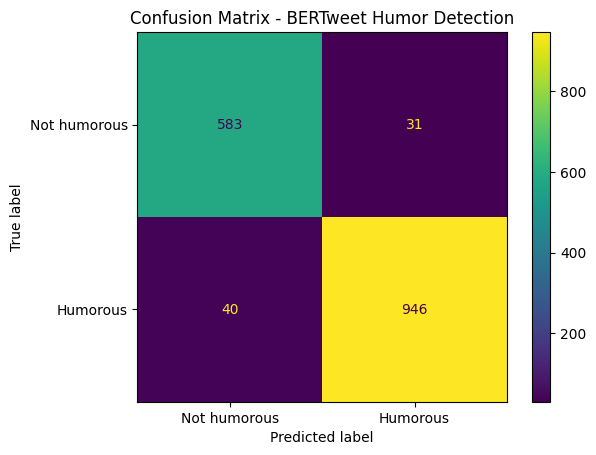

In [19]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not humorous", "Humorous"]
)

disp.plot()
plt.title("Confusion Matrix - BERTweet Humor Detection")
plt.show()

In [20]:
def predict_humor(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]

    pred = torch.argmax(probs).item()
    confidence = probs[pred].item()

    return {
        "label": "Humorous" if pred == 1 else "Not humorous",
        "confidence": confidence,
        "not_humorous_probability": probs[0].item(),
        "humorous_probability": probs[1].item()
    }

In [21]:
examples = [
    "I told my computer I needed a break, and now it won't stop sending me vacation ads.",
    "The database backup completed successfully.",
    "I used to play piano by ear, but now I use my hands.",
    "The meeting will start tomorrow at 10 AM.",
    "My cat looked at the expensive food I bought and decided starvation was more dignified."
]

for example in examples:
    print(example)
    print(predict_humor(example))
    print("-" * 60)

I told my computer I needed a break, and now it won't stop sending me vacation ads.
{'label': 'Humorous', 'confidence': 0.9990764856338501, 'not_humorous_probability': 0.0009235290344804525, 'humorous_probability': 0.9990764856338501}
------------------------------------------------------------
The database backup completed successfully.
{'label': 'Not humorous', 'confidence': 0.9900575280189514, 'not_humorous_probability': 0.9900575280189514, 'humorous_probability': 0.009942438453435898}
------------------------------------------------------------
I used to play piano by ear, but now I use my hands.
{'label': 'Humorous', 'confidence': 0.999045193195343, 'not_humorous_probability': 0.0009547881782054901, 'humorous_probability': 0.999045193195343}
------------------------------------------------------------
The meeting will start tomorrow at 10 AM.
{'label': 'Not humorous', 'confidence': 0.996894359588623, 'not_humorous_probability': 0.996894359588623, 'humorous_probability': 0.00310564

In [22]:
save_path = "./bertweet_humor_model"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bertweet_humor_model/tokenizer_config.json',
 './bertweet_humor_model/vocab.txt',
 './bertweet_humor_model/bpe.codes',
 './bertweet_humor_model/added_tokens.json')

In [23]:
!zip -r bertweet_humor_model.zip bertweet_humor_model

  adding: bertweet_humor_model/ (stored 0%)
  adding: bertweet_humor_model/added_tokens.json (stored 0%)
  adding: bertweet_humor_model/vocab.txt (deflated 50%)
  adding: bertweet_humor_model/training_args.bin (deflated 53%)
  adding: bertweet_humor_model/bpe.codes (deflated 57%)
  adding: bertweet_humor_model/config.json (deflated 52%)
  adding: bertweet_humor_model/tokenizer_config.json (deflated 76%)
  adding: bertweet_humor_model/model.safetensors (deflated 13%)


In [24]:
from google.colab import files
files.download("bertweet_humor_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>